# 01 Tax Baseline

Calculates the after-tax benchmark for selling today and shows after-tax sensitivity to future price moves.

**Plain English:**
This notebook figures out how much cash you would keep if you sold now, then compares that number with what you would keep if the price moved up or down and you sold later.

**This answers the question:** "What number does every hold, stop-loss, or re-entry strategy need to beat?"

Example:
If you own 35 shares at 350 with a 124 cost basis and 26% tax, selling today gives 10,193.40 after tax. A future strategy needs to produce more than 10,193.40 to be better than selling today.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from tax_risk_sim import (
    build_after_tax_sensitivity,
    build_bear_recovery_cases,
    build_bear_recovery_table,
    build_probability_weighted_scenarios,
    build_stop_benchmark,
    compare_stop_reentry_vs_hold,
    sell_today_baseline,
)

pd.options.display.float_format = "{:,.2f}".format

## Inputs

These are the starting assumptions for the position and sensitivity grid.

**Plain English:**
Change these numbers to match your actual position. The rest of the notebook recalculates from them.

**This answers the question:** "What position and price range am I analyzing?"

Example:
If `shares = 35` and `current_price = 350`, the current gross position value is 12,250 before tax.

### Input Explanations

`shares` is the number of shares currently held.

**Plain English:**
This is how many pieces of the investment you own.

**This answers the question:** "How large is my position?"

Example:
If `shares = 35`, every 1 price-unit move changes gross value by 35.

`current_price` is today's price per share.

**Plain English:**
This is the price you could use as today's reference point.

**This answers the question:** "What price am I measuring gains, losses, and stop levels from?"

Example:
If `current_price = 350`, a 20% stop is 280.

`cost_basis_per_share` is the purchase cost per share used to calculate taxable gains.

**Plain English:**
This is what the tax calculation treats as your original price.

**This answers the question:** "How much of today's value is taxable gain?"

Example:
If basis is 124 and current price is 350, the taxable gain per share is 226.

`capital_gains_tax_rate` is the flat capital-gains tax rate applied to positive gains.

**Plain English:**
This is the percentage of profit lost to tax when you sell.

**This answers the question:** "How much tax is removed from a profitable sale?"

Example:
If the gain is 7,910 and tax is 26%, tax is 2,056.60.

`stop_loss_drops` is shared with later notebooks; it is not used in every baseline output.

**Plain English:**
These are candidate drops like 5%, 10%, or 20%.

**This answers the question:** "Which stop levels will later notebooks test?"

Example:
A value of `0.20` means a 20% stop.

`min_return`, `max_return`, and `return_step` define the sensitivity grid for possible future price moves.

**Plain English:**
These say how far down/up to scan and how small each step should be.

**This answers the question:** "Which possible future price moves should the table show?"

Example:
`min_return = -0.80`, `max_return = 1.00`, and `return_step = 0.01` means -80% to +100% in 1% steps.

In [2]:
from inputs import (
    shares,
    current_price,
    cost_basis_per_share,
    capital_gains_tax_rate,
    stop_loss_drops,
    min_return,
    max_return,
    return_step,
)

In [ ]:
pd.Series(
    {
        "Shares held": shares,
        "Current price": f"${current_price:,.2f}",
        "Cost basis per share": f"${cost_basis_per_share:,.2f}",
        "Capital gains tax rate": f"{capital_gains_tax_rate:.0%}",
        "Stop-loss levels tested": ", ".join(f"{d:.0%}" for d in stop_loss_drops),
        "Sensitivity return range": (
            f"{min_return:.0%} to {max_return:.0%} in {return_step:.0%} steps"
        ),
    },
    name="Inputs",
)

## Sell Today Baseline

Computes the after-tax cash value if the position is sold today.

**Plain English:**
This is the cash you would actually keep if you sold now and paid tax on the gain.

**This answers the question:** "What is my guaranteed sell-now number?"

Example:
With 35 shares at 350, basis 124, and 26% tax, the sell-today value is 10,193.40 after tax.

In [3]:
baseline = sell_today_baseline(
    shares,
    current_price,
    cost_basis_per_share,
    capital_gains_tax_rate,
)

baseline

shares                                               35.00
current_price                                       350.00
cost_basis_per_share                                124.00
current_gross_value                              12,250.00
current_unrealized_gain                           7,910.00
tax_if_sold_today                                 2,056.60
sell_today_after_tax_value                       10,193.40
required_recovery_price_to_match_selling_today      350.00
dtype: float64

## After-Tax Return Sensitivity

This is salvaged from the exploratory notebook. It asks: if the future price move is X%, what is the after-tax liquidation value?

**Plain English:**
It shows how much cash you would keep after tax if the investment later falls or rises by different percentages.

**This answers the question:** "If the price changes, how much better or worse am I than selling today?"

Example:
If the future return is -20%, the future price is 280. The table shows the after-tax value at 280 and compares it with selling today.

### Sensitivity Column Explanations

`return` is the modeled future price move from today.

**Plain English:**
This is the percentage change being tested.

**This answers the question:** "How much did the price move?"

Example:
`-0.20` means the price fell 20%.

`future_price` is today's price adjusted by `return`.

**Plain English:**
This is the price after the modeled move.

**This answers the question:** "What price does that percentage move produce?"

Example:
350 with a -20% return becomes 280.

`after_tax_value_if_sold_later` is the liquidation value after applying tax to future gains.

**Plain English:**
This is the cash you keep if you sell at that future price.

**This answers the question:** "How much money would I keep after tax later?"

Example:
If the future price is 280, the table calculates the after-tax cash from selling at 280.

`tax_if_sold_later` is the tax due at that future price.

**Plain English:**
This is the tax bill at the future sale price.

**This answers the question:** "How much tax would I pay if I sold at that future price?"

Example:
If price falls, the taxable gain falls too, so the tax bill is lower.

`advantage_vs_selling_today` compares selling later at that future price against selling today after tax.

**Plain English:**
Positive means waiting was better; negative means selling today was better.

**This answers the question:** "Did waiting beat selling now?"

Example:
If this column is -1,000, selling later produced 1,000 less after tax than selling today.

In [4]:
sensitivity_df = build_after_tax_sensitivity(
    shares,
    current_price,
    cost_basis_per_share,
    capital_gains_tax_rate,
    min_return=min_return,
    max_return=max_return,
    return_step=return_step,
)

sensitivity_df

,return,future_price,after_tax_value_if_sold_later,tax_if_sold_later,advantage_vs_selling_today
0,-0.80,70.00,"2,450.00",0.00,"-7,743.40"
1,-0.79,73.50,"2,572.50",0.00,"-7,620.90"
2,-0.78,77.00,"2,695.00",0.00,"-7,498.40"
3,-0.77,80.50,"2,817.50",0.00,"-7,375.90"
4,-0.76,84.00,"2,940.00",0.00,"-7,253.40"
...,...,...,...,...,...
176,0.96,686.00,"18,895.80","5,114.20","8,702.40"
177,0.97,689.50,"18,986.45","5,146.05","8,793.05"
178,0.98,693.00,"19,077.10","5,177.90","8,883.70"
179,0.99,696.50,"19,167.75","5,209.75","8,974.35"


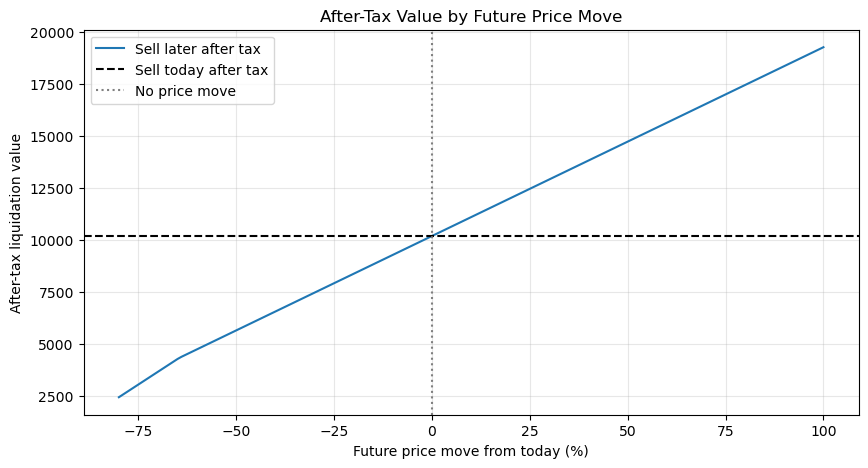

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(
    sensitivity_df["return"] * 100,
    sensitivity_df["after_tax_value_if_sold_later"],
    label="Sell later after tax",
)
ax.axhline(baseline["sell_today_after_tax_value"], color="black", linestyle="--", label="Sell today after tax")
ax.axvline(0, color="gray", linestyle=":", label="No price move")
ax.set_title("After-Tax Value by Future Price Move")
ax.set_xlabel("Future price move from today (%)")
ax.set_ylabel("After-tax liquidation value")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()